# Prjoect 6: Text Classification with Naive Bayes Classifier

In [92]:
# Load the libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('seaborn-v0_8')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import ComplementNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

## Problem Statement

### Project Overview

This project focuses on classifying emails as spam or non-spam using a Naive Bayes Classifier to automate email filtering. The dataset will be preprocessed, and a machine learning model will be developed to predict email labels, addressing challenges like class imbalance and text data handling.

**Business Task**  

Develop a model to accurately classify emails as spam or non-spam to improve email filtering efficiency and user experience.

**Technical Task** 

As a Data Science specialist, a machine learning model will be built to predict a binary label (spam or non-spam) based on email text features, solving a classification task.

**Main Objectives:**  

1. **`Comprehensive Data Exploration`**: Analyze the dataset to understand class distribution and text characteristics.  

2. **`Effective Preprocessing`**: Handle missing values and convert text into a suitable format for modeling. 

3. **`Innovative Approach`**: Optimize model performance through hyperparameter tuning and robust evaluation.

Open the dataset. Determine the number of spam and non-spam emails. Visualize the obtained ratio in an appropriate way

In [ ]:
# Load the dataset

data = pd.read_csv('data/spam_or_not_spam.csv')
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [74]:
# Check the class ratio in percentage

data['label'].value_counts(normalize=True)

label
0    0.833333
1    0.166667
Name: proportion, dtype: float64

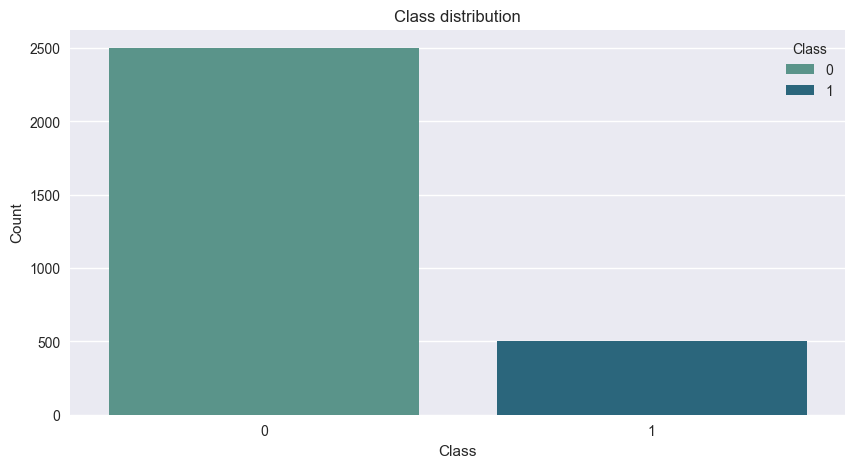

In [75]:
# Visualize the class ratio

plt.figure(figsize=(10, 5))
bardata = data.groupby('label').size().reset_index(name='count')
sns.barplot(x='label', y='count', hue='label', data=bardata, palette='crest')
plt.title('Class distribution')
plt.legend(title='Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show();

### We observe a clear imbalance in the class distribution in our sample

Need to preprocess data and convert it into a vectorized form. Let's import the necessary module

In [76]:
from sklearn.feature_extraction.text import CountVectorizer

Replace all empty strings and strings consisting of spaces in the data with missing values (NaN). After that, remove all rows with missing values from the data

In [77]:
# Replace empty strings and strings consisting of spaces with missing values, then remove these rows

data = data.replace(r'^\s*$', np.nan, regex=True)
data = data.dropna()

In [78]:
print(f'Data shape after handling missing values: {data.shape}')

Data shape after handling missing values: (2997, 2)


In [79]:
# Convert the data into vectorized form

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Determine the number of features in our dataset now:

In [80]:
# Check the number of features in our dataset now
print(f'Number of features: {X.shape[1]}')

Number of features: 34116


In [81]:
# Define the target variable and features:

y = data['label']
X = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

Split the dataset into training and testing sets using stratified splitting (set the `stratify` parameter to the vector of target values y). Use a test set size (`test_size`) of 0.25 and set the `random_state` parameter to 42:

In [82]:
# Split the dataset into training and testing sets using stratified splitting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Calculate the mean value of the target variable for the test set to check how data was splitted:

In [83]:
# Mean value of the target variable for the test set

y_test.mean().round(3)

0.165

Define and train an appropriate algorithm with the parameter alpha = 0.01

In [84]:
# Train the ComplementNB model using the parameter alpha=0.01

model = ComplementNB(alpha=0.01)
model.fit(X_train, y_train)

# Make predictions on the test set

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Prediction accuracy on the test set: {accuracy:.3f}')


Prediction accuracy on the test set: 0.988


Evaluate the results using at least three metrics you are familiar with: , target_names=['0', '1']

In [85]:
# Calculate f1-score, precision, recall using classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       626
           1       1.00      0.93      0.96       124

    accuracy                           0.99       750
   macro avg       0.99      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750



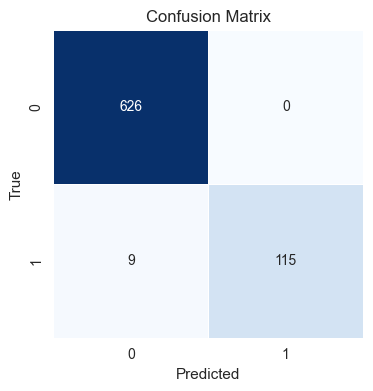

In [86]:
# Create a confusion matrix to check the model's performance and the obtained results

confusion = confusion_matrix(y_test, y_pred)
confusion_df = pd.DataFrame(confusion, index=['0', '1'], columns=['0', '1'])
plt.figure(figsize=(4, 4))
sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show();

### We observe a low number of falsely predicted responses for class 1

<Figure size 800x600 with 0 Axes>

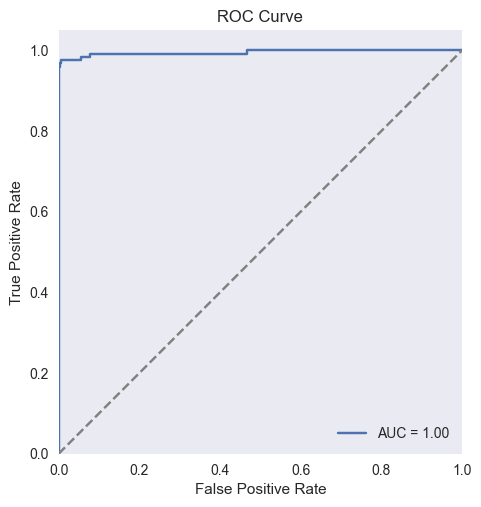

In [87]:
# Plot the ROC curve and calculate the AUC

y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = auc(fpr, tpr)
fig = plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show();

Iterate over several alpha values using cross-validation. Evaluate whether the classification quality depends on this parameter.

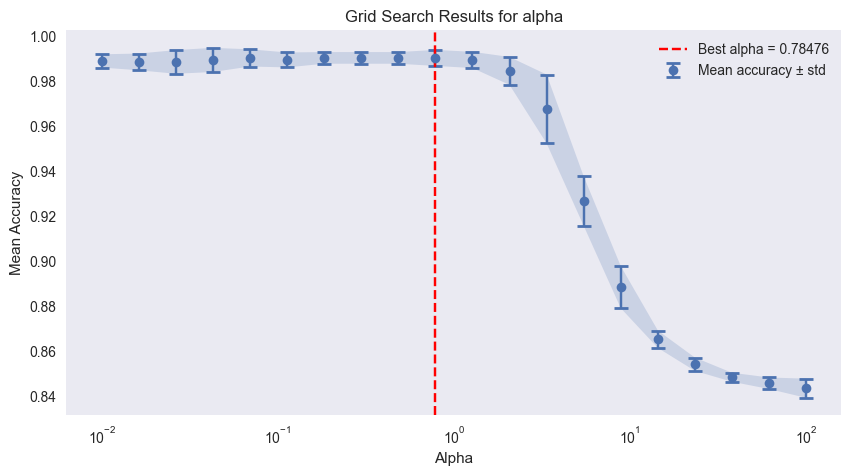

Best alpha value: 0.78476
Model accuracy at the best alpha value: 0.991
Parameter tuning time: 84.84 sec.


In [91]:
# Iterate over several alpha values using cross-validation. Using GridSearchCV

import time
start_time = time.time()

# Extended logarithmic grid of alpha values

alphas = np.logspace(-2, 2, 20)

model = ComplementNB()
param_grid = {'alpha': alphas}

# GridSearch with cross-validation

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    refit=True
)

grid_search.fit(X_train, y_train)

# Extract the best parameters and model

best_alpha = grid_search.best_params_['alpha']
best_accuracy = grid_search.best_score_
best_model = grid_search.best_estimator_

# Results in a DataFrame

results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_alpha', 'mean_test_score', 'std_test_score']]
results.columns = ['alpha', 'mean_accuracy', 'std_accuracy']
results['alpha'] = results['alpha'].astype(float)
results = results.sort_values(by='alpha')

# Visualization of the results

plt.figure(figsize=(10, 5))
plt.errorbar(results['alpha'], results['mean_accuracy'], yerr=results['std_accuracy'],
             fmt='o', capsize=5, capthick=2, label='Mean accuracy ± std')
plt.fill_between(results['alpha'],
                 results['mean_accuracy'] - results['std_accuracy'],
                 results['mean_accuracy'] + results['std_accuracy'],
                 alpha=0.2)
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha:.5f}')
plt.xscale('log')
plt.title('Grid Search Results for alpha')
plt.xlabel('Alpha')
plt.ylabel('Mean Accuracy')
plt.legend()
plt.grid()
plt.show()

print(f'Best alpha value: {best_alpha:.5f}')
print(f'Model accuracy at the best alpha value: {best_accuracy:.3f}')
print(f'Parameter tuning time: {round(time.time() - start_time, 2)} sec.')

### Up to an Alpha value of 1, the model demonstrates stable, high-quality prediction performance; beyond this, the quality significantly declines.